# 👍Enterprise Customer Intelligence Platform

## 📚 Table of Contents

## 1. Project Objective

## 2. Business Problem

## 3. Dataset Description

## 4. Files in Dataset

## 5. Questions We Want to Answer

## 6. Expected Business Impact

# 1. Project Objective

The objective of this project is to build an Enterprise Customer Intelligence Platform that helps businesses understand customer behavior using data science.

The platform will analyze customer transactions, purchasing patterns, customer demographics, product performance, and business metrics.

Using machine learning, the system will predict customer churn, estimate customer lifetime value, segment customers into different groups, and generate actionable business insights.

The final platform will assist business managers in making data-driven decisions that improve customer retention, increase revenue, and optimize marketing strategies.

# 2. Business Problem

Modern companies collect massive amounts of customer data every day.

However, most organizations do not fully utilize this information to improve business decisions.

Some common business problems include:

- Customers leave without warning.
- Marketing campaigns target the wrong customers.
- Companies don't know which customers are most valuable.
- Revenue decreases because customer behavior is not understood.
- Management lacks real-time business insights.

This project aims to solve these problems using data science and machine learning.

# 3. Dataset Description

The project uses an e-commerce customer dataset containing information about:

- Customer profiles
- Orders
- Products
- Payments
- Reviews
- Shipping
- Sellers
- Geolocation

The dataset represents the complete customer journey from placing an order to delivery and customer feedback.

It allows both business analytics and machine learning applications.

In [1]:
import pandas as pd
import os

In [4]:
os.listdir("data")

['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

# 4. Files in Dataset

The dataset consists of multiple CSV files representing different parts of the business.

These files capture customer information, product catalog, order history, seller information, payments, reviews, and geographic details.

Together they form a relational database that represents the complete business workflow.

In [5]:
files = os.listdir("data")

for file in files:
    print(file)

olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [6]:
import pandas as pd

summary = []

for file in files:
    df = pd.read_csv("data/" + file)
    
    summary.append({
        "File Name": file,
        "Rows": df.shape[0],
        "Columns": df.shape[1]
    })

summary_df = pd.DataFrame(summary)

summary_df

,File Name,Rows,Columns
0,olist_customers_dataset.csv,99441,5
1,olist_geolocation_dataset.csv,1000163,5
2,olist_orders_dataset.csv,99441,8
3,olist_order_items_dataset.csv,112650,7
4,olist_order_payments_dataset.csv,103886,5
5,olist_order_reviews_dataset.csv,99224,7
6,olist_products_dataset.csv,32951,9
7,olist_sellers_dataset.csv,3095,4
8,product_category_name_translation.csv,71,2


In [7]:
orders = pd.read_csv("data/olist_orders_dataset.csv")

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
orders.shape

(99441, 8)

In [9]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


# 5. Exploring Orders Dataset

The Orders dataset contains one record for every customer order.

It includes:

- Order ID
- Customer ID
- Order Status
- Purchase Timestamp
- Delivery Date
- Estimated Delivery Date

This dataset will act as the central table because every other dataset is connected with the Order ID.

In [10]:
orders.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [11]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

# 6. Orders Dataset Analysis

The orders table is the central dataset of the project.

Every purchase made by a customer is recorded here.

This dataset helps us understand:

- Total orders
- Order status
- Delivery performance
- Customer purchasing behavior
- Business operations

In [12]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [13]:
orders.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
78214,80f98860daea33485ed7375601bf94d6,e373476486d71774cb8ed05f84cb7c21,delivered,2018-01-30 09:00:20,2018-01-30 09:10:28,2018-01-31 14:32:21,2018-02-16 22:08:08,2018-03-06 00:00:00
71608,10631633611fba698054772b43dc118c,087924f653ede8ac260c3d6cec755a4b,delivered,2017-06-22 14:03:48,2017-06-22 14:22:58,2017-06-30 09:44:44,2017-07-07 17:47:40,2017-07-14 00:00:00
13939,eb92f6fdb8dcd9a9ab21c341b4a3ca5f,78a0a4fe355394a8f2ab9efd5fa38206,delivered,2018-02-09 02:14:32,2018-02-10 02:10:23,2018-02-14 18:38:23,2018-02-22 14:37:50,2018-02-23 00:00:00
55544,7f816e4b356f543be68cf6c0fbda9d62,ff87e254d164dee48c4db2b4ec462684,delivered,2017-11-16 12:15:20,2017-11-16 12:31:40,2017-11-16 19:33:08,2017-11-21 13:19:03,2017-12-04 00:00:00
60637,c99763ba8bcad2845131b6e9d2f203fc,781fa4901df881dd232d4c813b933cf1,delivered,2017-08-27 17:51:48,2017-08-27 18:04:34,2017-09-06 21:25:50,2017-09-18 19:57:42,2017-09-19 00:00:00


In [14]:
print("Rows :", orders.shape[0])
print("Columns :", orders.shape[1])

Rows : 99441
Columns : 8


In [15]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [16]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [17]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [18]:
orders.duplicated().sum()

0

In [19]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [20]:
orders["order_status"].value_counts(normalize=True) * 100

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

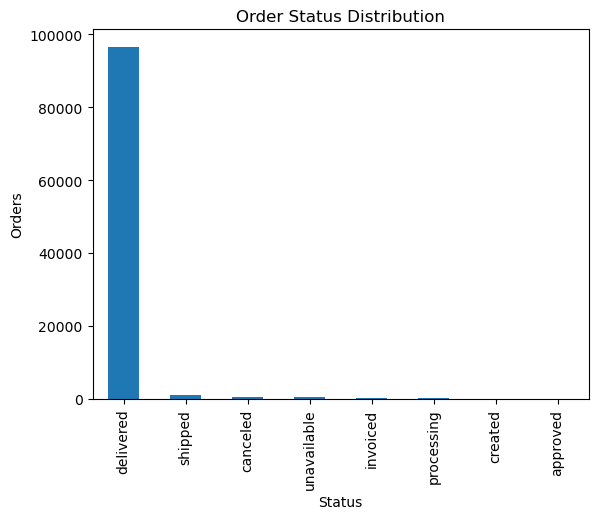

In [21]:
import matplotlib.pyplot as plt

orders["order_status"].value_counts().plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Status")
plt.ylabel("Orders")

plt.show()

## Business Insights

Most customer orders are successfully delivered.

A very small percentage of orders are cancelled or unavailable.

This indicates that the company has a strong fulfillment process.

Cancelled orders should still be investigated because reducing cancellations can directly increase revenue and improve customer satisfaction.

In [22]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

In [23]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

In [24]:
orders["delivery_days"].mean()

12.094085575687217

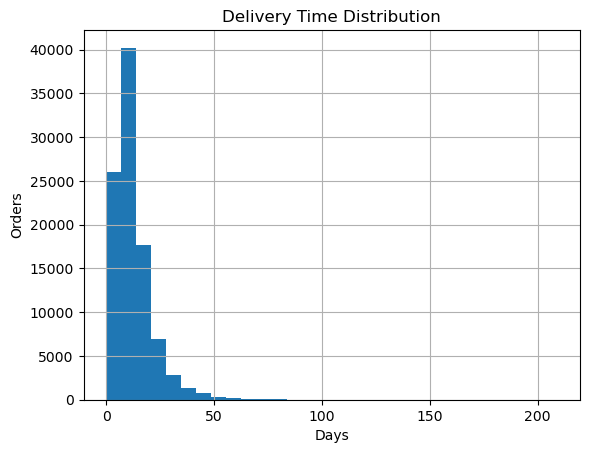

In [25]:
orders["delivery_days"].hist(bins=30)

plt.title("Delivery Time Distribution")

plt.xlabel("Days")

plt.ylabel("Orders")

plt.show()

## Delivery Analysis

The average delivery time helps evaluate logistics performance.

Long delivery times may increase customer dissatisfaction and lead to negative reviews.

Reducing delivery time can significantly improve customer retention.